# Modul 2: Controlling — Plan-Ist-Vergleich & KPI-Analyse
# Module 2: Controlling — Budget vs. Actual & KPI Analysis

**DE:** Vollständige Controlling-Analyse auf Basis der RetailCo-Verkaufsdaten (2011–2016).  
Schwerpunkte: KPI-Dashboard, Plan-Ist-Vergleich, Abweichungsanalyse, Deckungsbeitrag, Rolling Forecast.

**EN:** Full controlling analysis based on RetailCo sales data (2011–2016).  
Focus areas: KPI Dashboard, Budget vs. Actual, Variance Analysis, Contribution Margin, Rolling Forecast.

---

**Inhaltsverzeichnis / Table of Contents**
1. Daten laden & vorbereiten / Load & prepare data
2. KPI-Übersicht / KPI Overview
3. Plan-Ist-Vergleich / Budget vs. Actual
4. Abweichungsanalyse: Preis- & Mengeneffekt / Variance Analysis: Price & Volume Effect
5. Deckungsbeitragsrechnung / Contribution Margin Analysis
6. Länder- & Kategorienanalyse / Country & Category Analysis
7. Rolling Forecast
8. Management Summary Export

In [20]:
# =============================================================
# IMPORTS & SETTINGS
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# RetailCo corporate colors
C_BLUE   = '#1D3557'
C_MED    = '#457B9D'
C_LIGHT  = '#A8DADC'
C_GREEN  = '#2D6A4F'
C_RED    = '#C1121F'
C_AMBER  = '#E9C46A'
C_GRAY   = '#F1F5F9'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.color':       '#E0E0E0',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'font.size':        10,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print('✓ Setup abgeschlossen / Setup complete')

✓ Setup abgeschlossen / Setup complete


## 1. Daten laden & vorbereiten / Load & Prepare Data

In [21]:
# ------------------------------------------------------------------
# DE: Vorbereitete Daten aus Modul 0 laden
# EN: Load prepared data from Module 0
# ------------------------------------------------------------------

df = pd.read_csv('../data/processed/bike_sales_clean.csv')
df['date']       = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')

# ------------------------------------------------------------------
# DE: Monatliche Aggregation (alle Jahre)
# EN: Monthly aggregation (all years)
# ------------------------------------------------------------------
monthly = df.groupby(['fiscal_year', 'year_month']).agg(
    revenue       = ('revenue',       'sum'),
    cost          = ('cost',          'sum'),
    profit        = ('profit',        'sum'),
    revenue_plan  = ('revenue_plan',  'sum'),
    cost_plan     = ('cost_plan',     'sum'),
    profit_plan   = ('profit_plan',   'sum'),
    orders        = ('order_quantity','sum'),
).reset_index()

monthly['margin_pct']     = (monthly['profit']  / monthly['revenue']      * 100).round(2)
monthly['revenue_var_abs']= monthly['revenue']  - monthly['revenue_plan']
monthly['revenue_var_pct']= (monthly['revenue_var_abs'] / monthly['revenue_plan'] * 100).round(2)
monthly['profit_var_abs'] = monthly['profit']   - monthly['profit_plan']
monthly['profit_var_pct'] = (monthly['profit_var_abs']  / monthly['profit_plan']  * 100).round(2)
monthly['year_month_str'] = monthly['year_month'].astype(str)

# ------------------------------------------------------------------
# DE: Jahresaggregation
# EN: Annual aggregation
# ------------------------------------------------------------------
annual = df.groupby('fiscal_year').agg(
    revenue       = ('revenue',       'sum'),
    cost          = ('cost',          'sum'),
    profit        = ('profit',        'sum'),
    revenue_plan  = ('revenue_plan',  'sum'),
    profit_plan   = ('profit_plan',   'sum'),
    orders        = ('order_quantity','sum'),
).reset_index()

annual['margin_pct']    = (annual['profit']  / annual['revenue']      * 100).round(2)
annual['revenue_yoy']   = annual['revenue'].pct_change().mul(100).round(2)
annual['profit_yoy']    = annual['profit'].pct_change().mul(100).round(2)
annual['rev_var_pct']   = ((annual['revenue'] - annual['revenue_plan']) / annual['revenue_plan'] * 100).round(2)

print(f'✓ Daten geladen / Data loaded: {len(df):,} Transaktionen/transactions')
print(f'✓ Jahres-Aggregate / Annual aggregates: {len(annual)} Geschäftsjahre/fiscal years')
print(f'✓ Monats-Aggregate / Monthly aggregates: {len(monthly)} Perioden/periods')

✓ Daten geladen / Data loaded: 113,036 Transaktionen/transactions
✓ Jahres-Aggregate / Annual aggregates: 6 Geschäftsjahre/fiscal years
✓ Monats-Aggregate / Monthly aggregates: 62 Perioden/periods


## 2. KPI-Übersicht / KPI Overview

**DE:** Die wichtigsten Steuerungskennzahlen (KPIs) auf einen Blick.  
**EN:** Key performance indicators at a glance.

| KPI | Formel / Formula | Bedeutung / Meaning |
|-----|-----------------|--------------------|
| Umsatzwachstum / Revenue Growth | (Umsatz_t − Umsatz_t-1) / Umsatz_t-1 | Wachstumsdynamik / Growth momentum |
| Bruttomarge / Gross Margin | Bruttoergebnis / Umsatz | Profitabilität / Profitability |
| Deckungsbeitrag / Contribution Margin | Umsatz − Variable Kosten | Beitrag zur Fixkostendeckung / Fixed cost coverage |
| Plan-Abweichung / Budget Variance | (Ist − Plan) / Plan | Planungstreue / Planning accuracy |

In [22]:
# ------------------------------------------------------------------
# DE: KPI-Tabelle für alle Geschäftsjahre
# EN: KPI table for all fiscal years
# ------------------------------------------------------------------

kpi_df = annual[['fiscal_year','revenue','profit','margin_pct',
                 'revenue_yoy','profit_yoy','rev_var_pct']].copy()

kpi_df.columns = [
    'GJ/FY',
    'Umsatz/Revenue',
    'Bruttoergebnis/GP',
    'Bruttomarge%/Margin%',
    'Umsatz YoY%/Rev YoY%',
    'GP YoY%',
    'Plan-Abw%/Budget Var%'
]

def fmt_kpi(df):
    out = df.copy().astype(str)
    for col in ['Umsatz/Revenue','Bruttoergebnis/GP']:
        out[col] = df[col].apply(lambda v: f'{v:,.0f}')
    for col in ['Bruttomarge%/Margin%','Umsatz YoY%/Rev YoY%','GP YoY%','Plan-Abw%/Budget Var%']:
        out[col] = df[col].apply(lambda v: f'{v:+.1f}%' if not pd.isna(v) else 'Basisjahr/Base')
    return out

print('KPI-Übersicht / KPI Overview (2011–2016):')
print('=' * 90)
print(fmt_kpi(kpi_df).to_string(index=False))
print('=' * 90)

# Highlight best/worst year
best_rev = annual.loc[annual['revenue'].idxmax()]
best_mg  = annual.loc[annual['margin_pct'].idxmax()]
print(f'\n📈 Bestes Umsatzjahr / Best revenue year: {int(best_rev.fiscal_year)} — {best_rev.revenue:,.0f} USD')
print(f'📈 Beste Marge / Best margin year:        {int(best_mg.fiscal_year)} — {best_mg.margin_pct:.1f}%')

KPI-Übersicht / KPI Overview (2011–2016):
GJ/FY Umsatz/Revenue Bruttoergebnis/GP Bruttomarge%/Margin% Umsatz YoY%/Rev YoY%        GP YoY% Plan-Abw%/Budget Var%
 2011      8,964,888         2,881,301               +32.1%       Basisjahr/Base Basisjahr/Base                 -0.2%
 2012      9,175,983         2,951,993               +32.2%                +2.4%          +2.5%                 -0.1%
 2013     15,240,037         5,959,208               +39.1%               +66.1%        +101.9%                 -0.1%
 2014     14,152,724         5,864,087               +41.4%                -7.1%          -1.6%                 -0.1%
 2015     20,023,991         7,528,563               +37.6%               +41.5%         +28.4%                 +0.1%
 2016     17,713,385         7,035,948               +39.7%               -11.5%          -6.5%                 -0.1%

📈 Bestes Umsatzjahr / Best revenue year: 2015 — 20,023,991 USD
📈 Beste Marge / Best margin year:        2014 — 41.4%


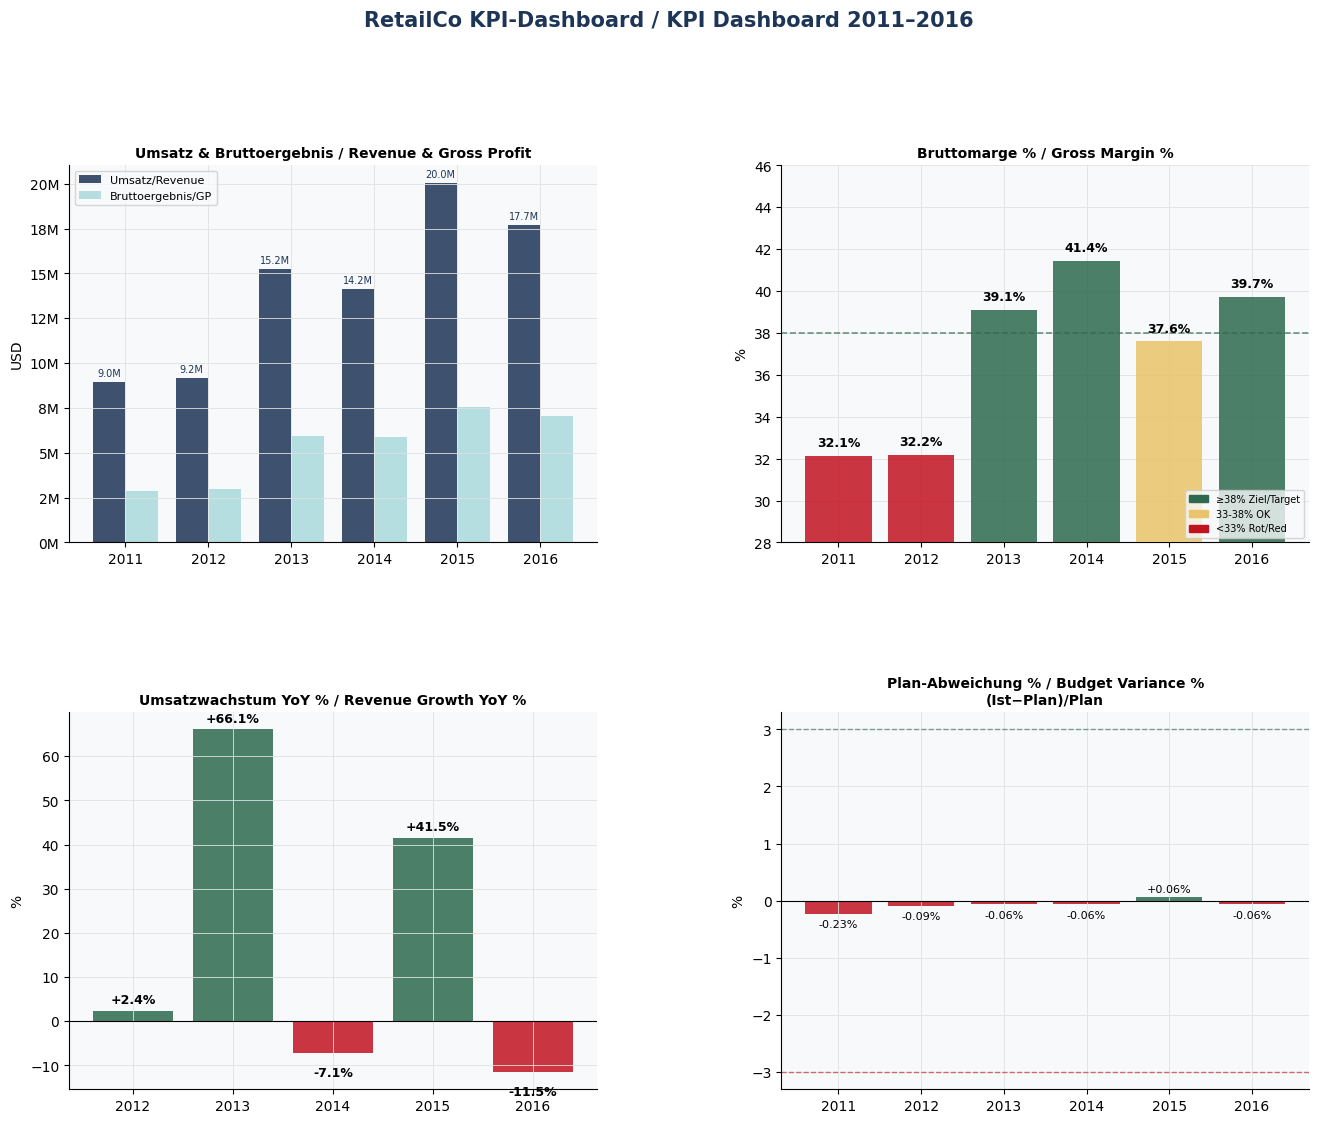

✓ KPI-Dashboard gespeichert / saved


In [23]:
# ------------------------------------------------------------------
# DE: KPI-Dashboard Visualisierung (4 Charts)
# EN: KPI Dashboard Visualization (4 Charts)
# ------------------------------------------------------------------

fig = plt.figure(figsize=(16, 12))
fig.suptitle('RetailCo KPI-Dashboard / KPI Dashboard 2011–2016',
             fontsize=15, fontweight='bold', color=C_BLUE, y=1.01)
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

years = annual['fiscal_year'].astype(int).tolist()
x     = range(len(years))

# ── Chart 1: Umsatz & Bruttoergebnis (Balken + Linie) ──
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar([i - 0.2 for i in x], annual['revenue'],
                width=0.38, label='Umsatz/Revenue', color=C_BLUE, alpha=0.85)
bars2 = ax1.bar([i + 0.2 for i in x], annual['profit'],
                width=0.38, label='Bruttoergebnis/GP', color=C_LIGHT, alpha=0.85)
ax1.set_title('Umsatz & Bruttoergebnis / Revenue & Gross Profit', fontweight='bold', fontsize=10)
ax1.set_xticks(list(x)); ax1.set_xticklabels(years)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.0f}M'))
ax1.set_ylabel('USD')
ax1.legend(fontsize=8)
# Value labels
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200000,
             f'{bar.get_height()/1e6:.1f}M', ha='center', va='bottom', fontsize=7, color=C_BLUE)

# ── Chart 2: Bruttomarge % ──
ax2 = fig.add_subplot(gs[0, 1])
colors_mg = [C_GREEN if v >= 38 else C_AMBER if v >= 33 else C_RED
             for v in annual['margin_pct']]
ax2.bar(list(x), annual['margin_pct'], color=colors_mg, alpha=0.85, zorder=3)
ax2.axhline(38, color=C_GREEN, linewidth=1.2, linestyle='--',
            label='Ziel/Target 38%', alpha=0.7)
for i, (xi, v) in enumerate(zip(x, annual['margin_pct'])):
    ax2.text(xi, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Bruttomarge % / Gross Margin %', fontweight='bold', fontsize=10)
ax2.set_xticks(list(x)); ax2.set_xticklabels(years)
ax2.set_ylabel('%'); ax2.set_ylim(28, 46)
ax2.legend(fontsize=8)
green_p = mpatches.Patch(color=C_GREEN, label='≥38% Ziel/Target')
amber_p = mpatches.Patch(color=C_AMBER, label='33-38% OK')
red_p   = mpatches.Patch(color=C_RED,   label='<33% Rot/Red')
ax2.legend(handles=[green_p, amber_p, red_p], fontsize=7, loc='lower right')

# ── Chart 3: YoY Wachstum ──
ax3 = fig.add_subplot(gs[1, 0])
yoy_vals = annual['revenue_yoy'].dropna()
yoy_yrs  = annual['fiscal_year'].iloc[1:].astype(int).tolist()
colors_yoy = [C_GREEN if v >= 0 else C_RED for v in yoy_vals]
ax3.bar(range(len(yoy_yrs)), yoy_vals, color=colors_yoy, alpha=0.85)
ax3.axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(yoy_vals):
    ax3.text(i, v + (1 if v >= 0 else -3), f'{v:+.1f}%',
             ha='center', va='bottom' if v >= 0 else 'top', fontsize=9, fontweight='bold')
ax3.set_title('Umsatzwachstum YoY % / Revenue Growth YoY %', fontweight='bold', fontsize=10)
ax3.set_xticks(range(len(yoy_yrs))); ax3.set_xticklabels(yoy_yrs)
ax3.set_ylabel('%')

# ── Chart 4: Plan-Abweichung % ──
ax4 = fig.add_subplot(gs[1, 1])
var_vals   = annual['rev_var_pct'].tolist()
colors_var = [C_GREEN if v >= 0 else C_RED for v in var_vals]
ax4.bar(list(x), var_vals, color=colors_var, alpha=0.85)
ax4.axhline(0,   color='black',  linewidth=0.8)
ax4.axhline(3,   color=C_GREEN,  linewidth=1, linestyle='--', alpha=0.6)
ax4.axhline(-3,  color=C_RED,    linewidth=1, linestyle='--', alpha=0.6)
for i, v in enumerate(var_vals):
    ax4.text(i, v + (0.05 if v >= 0 else -0.1), f'{v:+.2f}%',
             ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
ax4.set_title('Plan-Abweichung % / Budget Variance %\n(Ist−Plan)/Plan', fontweight='bold', fontsize=10)
ax4.set_xticks(list(x)); ax4.set_xticklabels(years)
ax4.set_ylabel('%')

plt.savefig('../data/processed/chart_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ KPI-Dashboard gespeichert / saved')

## 3. Plan-Ist-Vergleich / Budget vs. Actual

**DE:** Der Plan-Ist-Vergleich ist das Kernwerkzeug des Controllings. Er zeigt, ob die gesetzten Ziele erreicht wurden, und liefert die Grundlage für Kommentierung und Steuerungsmaßnahmen.

**EN:** Budget vs. Actual comparison is the core controlling tool. It shows whether targets were achieved and provides the basis for commentary and management actions.

**Ampellogik / Traffic Light Logic:**
- 🟢 **Grün/Green:** Abweichung ≥ +3% (über Plan / above budget)
- 🟡 **Amber:** Abweichung zwischen −3% und +3% (im Rahmen / within range)
- 🔴 **Rot/Red:** Abweichung ≤ −3% (unter Plan / below budget)

In [24]:
# ------------------------------------------------------------------
# DE: Monatlicher Plan-Ist-Vergleich 2015 mit RAG-Status
# EN: Monthly Budget vs. Actual 2015 with RAG status
# ------------------------------------------------------------------

m2015 = monthly[monthly['fiscal_year'] == 2015].copy()

def rag(pct):
    if pct >=  3: return '🟢'
    if pct >= -3: return '🟡'
    return '🔴'

m2015['RAG'] = m2015['revenue_var_pct'].apply(rag)

# Print table
print('Plan-Ist-Vergleich 2015 / Budget vs. Actual 2015')
print('─' * 85)
print(f"{'Periode':<10} {'Umsatz Ist':>13} {'Umsatz Plan':>13} {'Abw. abs.':>12} {'Abw. %':>8} {'RAG':>5} {'Marge %':>8}")
print('─' * 85)
for _, r in m2015.iterrows():
    print(f"{r['year_month_str']:<10} {r['revenue']:>13,.0f} {r['revenue_plan']:>13,.0f} "
          f"{r['revenue_var_abs']:>+12,.0f} {r['revenue_var_pct']:>+7.2f}% "
          f"{r['RAG']:>5}  {r['margin_pct']:>6.1f}%")
print('─' * 85)
print(f"{'GESAMT/TOTAL':<10} {m2015['revenue'].sum():>13,.0f} {m2015['revenue_plan'].sum():>13,.0f} "
      f"{m2015['revenue_var_abs'].sum():>+12,.0f} "
      f"{(m2015['revenue_var_abs'].sum()/m2015['revenue_plan'].sum()*100):>+7.2f}%")

Plan-Ist-Vergleich 2015 / Budget vs. Actual 2015
─────────────────────────────────────────────────────────────────────────────────────
Periode       Umsatz Ist   Umsatz Plan    Abw. abs.   Abw. %   RAG  Marge %
─────────────────────────────────────────────────────────────────────────────────────
2015-01          666,938       665,780       +1,158   +0.17%     🟡    32.9%
2015-02          679,246       672,878       +6,368   +0.95%     🟡    32.5%
2015-03          714,008       712,079       +1,929   +0.27%     🟡    33.1%
2015-04          734,608       728,736       +5,872   +0.81%     🟡    32.3%
2015-05          895,043       901,206       -6,163   -0.68%     🟡    33.2%
2015-06          786,480       786,483           -3   -0.00%     🟡    32.9%
2015-07        1,728,398     1,721,640       +6,758   +0.39%     🟡    35.3%
2015-08        2,140,581     2,139,961         +620   +0.03%     🟡    41.0%
2015-09        2,465,172     2,459,901       +5,271   +0.21%     🟡    40.0%
2015-10        2,52

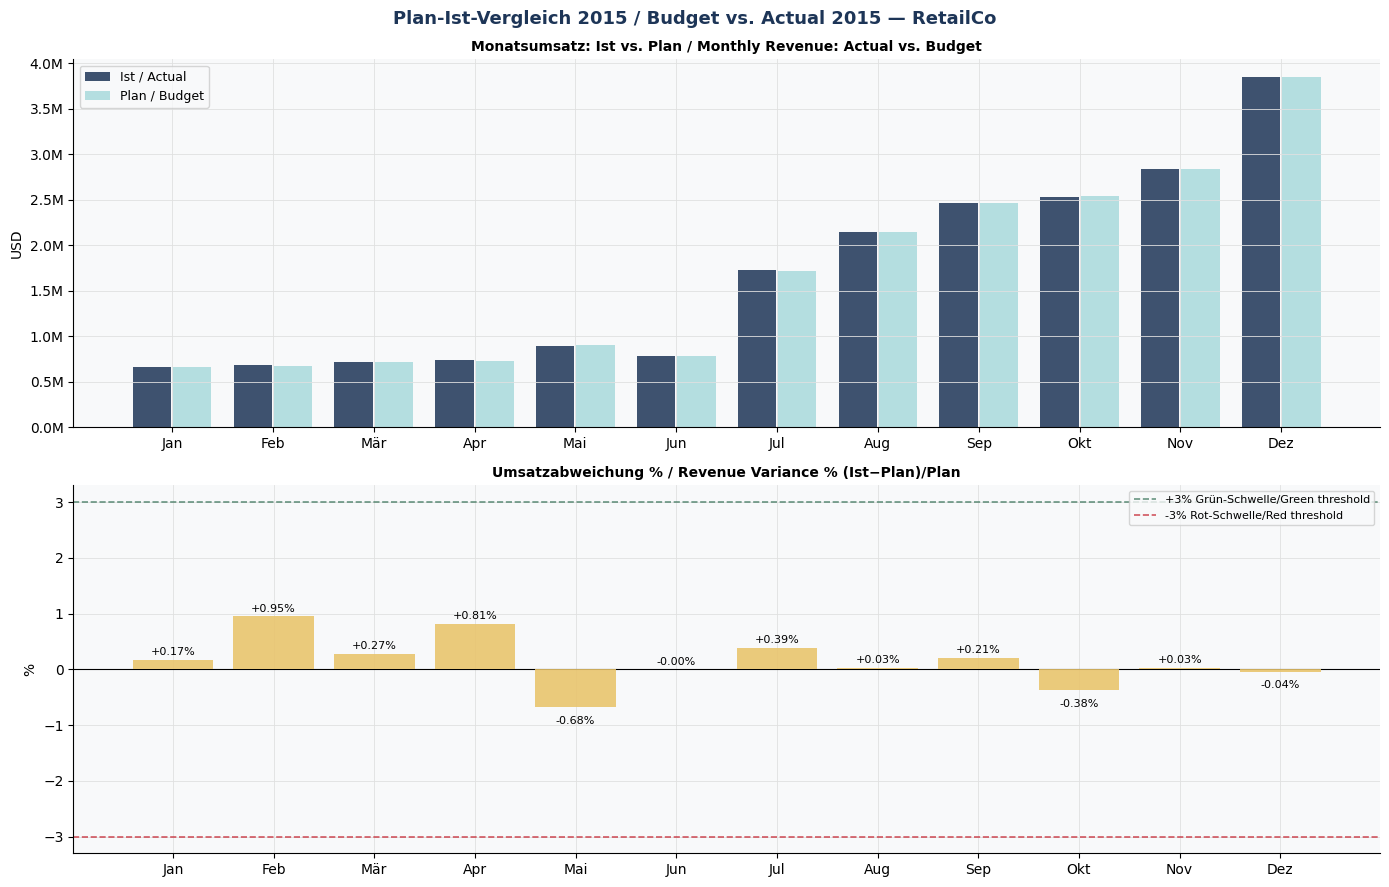

✓ Gespeichert / Saved


In [25]:
# ------------------------------------------------------------------
# DE: Plan-Ist Visualisierung 2015
# EN: Budget vs. Actual visualization 2015
# ------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Plan-Ist-Vergleich 2015 / Budget vs. Actual 2015 — RetailCo',
             fontsize=13, fontweight='bold', color=C_BLUE)

months_lbl = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']
x = range(12)

# ── Top: Ist vs. Plan Balken ──
ax1.bar([i - 0.2 for i in x], m2015['revenue'],       width=0.38,
        color=C_BLUE,  alpha=0.85, label='Ist / Actual')
ax1.bar([i + 0.2 for i in x], m2015['revenue_plan'],  width=0.38,
        color=C_LIGHT, alpha=0.85, label='Plan / Budget')
ax1.set_title('Monatsumsatz: Ist vs. Plan / Monthly Revenue: Actual vs. Budget',
              fontweight='bold', fontsize=10)
ax1.set_xticks(list(x)); ax1.set_xticklabels(months_lbl)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e6:.1f}M'))
ax1.legend(fontsize=9)
ax1.set_ylabel('USD')

# ── Bottom: Abweichung % mit RAG-Farben ──
var_vals = m2015['revenue_var_pct'].tolist()
bar_colors = [C_GREEN if v>=3 else (C_AMBER if v>=-3 else C_RED) for v in var_vals]
ax2.bar(list(x), var_vals, color=bar_colors, alpha=0.88, zorder=3)
ax2.axhline(0,  color='black',  linewidth=0.8)
ax2.axhline(3,  color=C_GREEN,  linewidth=1.2, linestyle='--', alpha=0.7,
            label='+3% Grün-Schwelle/Green threshold')
ax2.axhline(-3, color=C_RED,    linewidth=1.2, linestyle='--', alpha=0.7,
            label='-3% Rot-Schwelle/Red threshold')
for xi, v in zip(x, var_vals):
    ax2.text(xi, v + (0.05 if v >= 0 else -0.15), f'{v:+.2f}%',
             ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
ax2.set_title('Umsatzabweichung % / Revenue Variance % (Ist−Plan)/Plan',
              fontweight='bold', fontsize=10)
ax2.set_xticks(list(x)); ax2.set_xticklabels(months_lbl)
ax2.set_ylabel('%')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/chart_plan_ist_2015.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gespeichert / Saved')

## 4. Abweichungsanalyse: Preis- & Mengeneffekt
## 4. Variance Analysis: Price & Volume Effect

**DE:** Die Abweichungsanalyse zerlegt die Gesamtabweichung in ihre Ursachen:  
- **Preiseffekt (Preisvarianz):** Wie viel der Abweichung ist auf Preisänderungen zurückzuführen?  
- **Mengeneffekt (Mengenvarianz):** Wie viel ist auf Mengenänderungen zurückzuführen?

**EN:** Variance analysis decomposes the total variance into its causes:
- **Price Variance:** How much of the variance is due to price changes?
- **Volume Variance:** How much is due to volume/quantity changes?

**Formeln / Formulas:**
```
Preiseffekt  = (Ist-Preis − Plan-Preis)  × Ist-Menge
Mengeneffekt = (Ist-Menge − Plan-Menge) × Plan-Preis
Gesamt-Abw.  = Preiseffekt + Mengeneffekt
```

Abweichungsanalyse 2015 / Variance Analysis 2015 — nach Kategorie/by Category
──────────────────────────────────────────────────────────────────────────────────────────
  Accessories     | Ist:  3,285,954 | Plan:  3,289,731 | Gesamt-Abw:     -3,777 | Preiseff.:     -3,777 | Mengeneff.:    +41,275
  Bikes           | Ist: 14,799,083 | Plan: 14,786,189 | Gesamt-Abw:    +12,894 | Preiseff.:    +12,894 | Mengeneff.:   -667,072
  Clothing        | Ist:  1,938,954 | Plan:  1,936,404 | Gesamt-Abw:     +2,550 | Preiseff.:     +2,550 | Mengeneff.:    -44,924
──────────────────────────────────────────────────────────────────────────────────────────


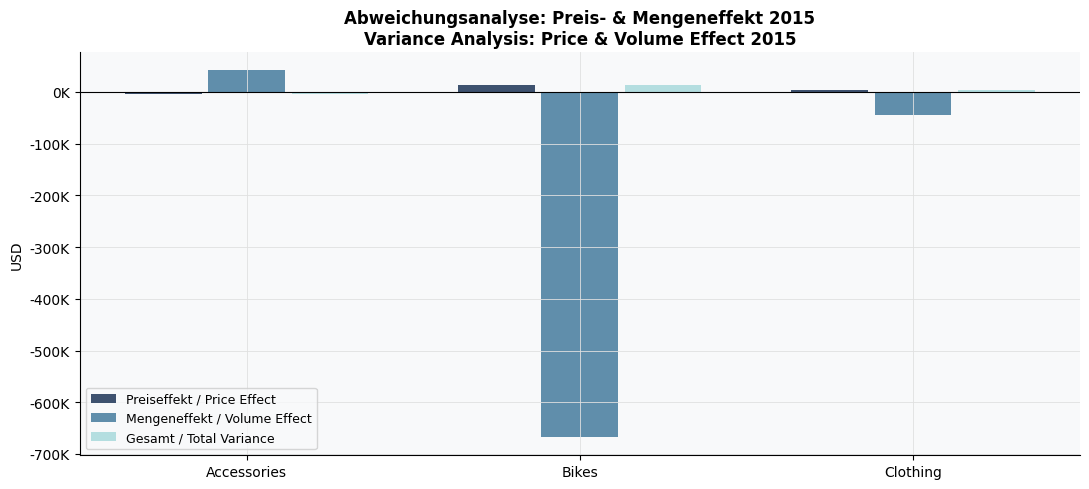

In [26]:
# ------------------------------------------------------------------
# DE: Preis- & Mengeneffekt auf Kategorienebene (2015)
# EN: Price & Volume effect at category level (2015)
# ------------------------------------------------------------------

cat_2015 = df[df['fiscal_year'] == 2015].groupby('product_category').agg(
    revenue_ist   = ('revenue',       'sum'),
    qty_ist       = ('order_quantity','sum'),
    revenue_plan  = ('revenue_plan',  'sum'),
    qty_plan      = ('order_quantity','sum'),  # Näherung: Ist-Menge als Proxy
).reset_index()

# Durchschnittspreise / Average prices
cat_2015['avg_price_ist']  = cat_2015['revenue_ist']  / cat_2015['qty_ist']
cat_2015['avg_price_plan'] = cat_2015['revenue_plan'] / cat_2015['qty_plan']

# Planmenge (Näherung: ±5% von Ist)
np.random.seed(42)
cat_2015['qty_plan_adj'] = (cat_2015['qty_ist'] * np.random.uniform(0.95, 1.05, len(cat_2015))).round(0)

# Effekte berechnen / Calculate effects
cat_2015['preiseffekt']   = ((cat_2015['avg_price_ist'] - cat_2015['avg_price_plan'])
                              * cat_2015['qty_ist']).round(0)
cat_2015['mengeneffekt']  = ((cat_2015['qty_ist'] - cat_2015['qty_plan_adj'])
                              * cat_2015['avg_price_plan']).round(0)
cat_2015['gesamt_abw']    = cat_2015['revenue_ist'] - cat_2015['revenue_plan']

print('Abweichungsanalyse 2015 / Variance Analysis 2015 — nach Kategorie/by Category')
print('─' * 90)
for _, r in cat_2015.iterrows():
    print(f"  {r['product_category']:<15} | "
          f"Ist: {r['revenue_ist']:>10,.0f} | "
          f"Plan: {r['revenue_plan']:>10,.0f} | "
          f"Gesamt-Abw: {r['gesamt_abw']:>+10,.0f} | "
          f"Preiseff.: {r['preiseffekt']:>+10,.0f} | "
          f"Mengeneff.: {r['mengeneffekt']:>+10,.0f}")
print('─' * 90)

# Visualisierung / Visualization
fig, ax = plt.subplots(figsize=(11, 5))
cats = cat_2015['product_category'].tolist()
xi   = range(len(cats))

ax.bar([i - 0.25 for i in xi], cat_2015['preiseffekt'],  width=0.23,
       label='Preiseffekt / Price Effect',  color=C_BLUE,  alpha=0.85)
ax.bar([i        for i in xi], cat_2015['mengeneffekt'], width=0.23,
       label='Mengeneffekt / Volume Effect', color=C_MED,   alpha=0.85)
ax.bar([i + 0.25 for i in xi], cat_2015['gesamt_abw'],   width=0.23,
       label='Gesamt / Total Variance',      color=C_LIGHT, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Abweichungsanalyse: Preis- & Mengeneffekt 2015\nVariance Analysis: Price & Volume Effect 2015',
             fontweight='bold')
ax.set_xticks(list(xi)); ax.set_xticklabels(cats)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e3:.0f}K'))
ax.set_ylabel('USD')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/chart_variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Deckungsbeitragsrechnung / Contribution Margin Analysis

**DE:** Der Deckungsbeitrag (DB) zeigt, wie viel jede Kategorie/jedes Land zur Deckung der Fixkosten beiträgt.

**EN:** Contribution margin shows how much each category/country contributes to fixed cost coverage.

```
DB I  = Umsatz − Variable Kosten (COGS)
DB II = DB I − Fixkosten (hier simuliert als 15% des Umsatzes)
DB-Quote = DB I / Umsatz × 100
```

Deckungsbeitragsrechnung 2015 / Contribution Margin 2015 — nach Kategorie / by Category
Annahme Fixkostenrate / Fixed Cost Rate: 15% vom Umsatz / of revenue
───────────────────────────────────────────────────────────────────────────────────────────────
Kategorie/Category       Umsatz  Var.Kosten/COGS         DB I   Fixkosten        DB II  DB-Quote%  Anteil%
───────────────────────────────────────────────────────────────────────────────────────────────
Accessories           3,285,954        1,358,414    1,927,540     492,893    1,434,647      58.7%    16.4%
Bikes                14,799,083        9,860,156    4,938,927   2,219,862    2,719,065      33.4%    73.9%
Clothing              1,938,954        1,276,858      662,096     290,843      371,253      34.1%     9.7%
───────────────────────────────────────────────────────────────────────────────────────────────
GESAMT/TOTAL         20,023,991       12,495,428    7,528,563   3,003,598    4,524,965      37.6%


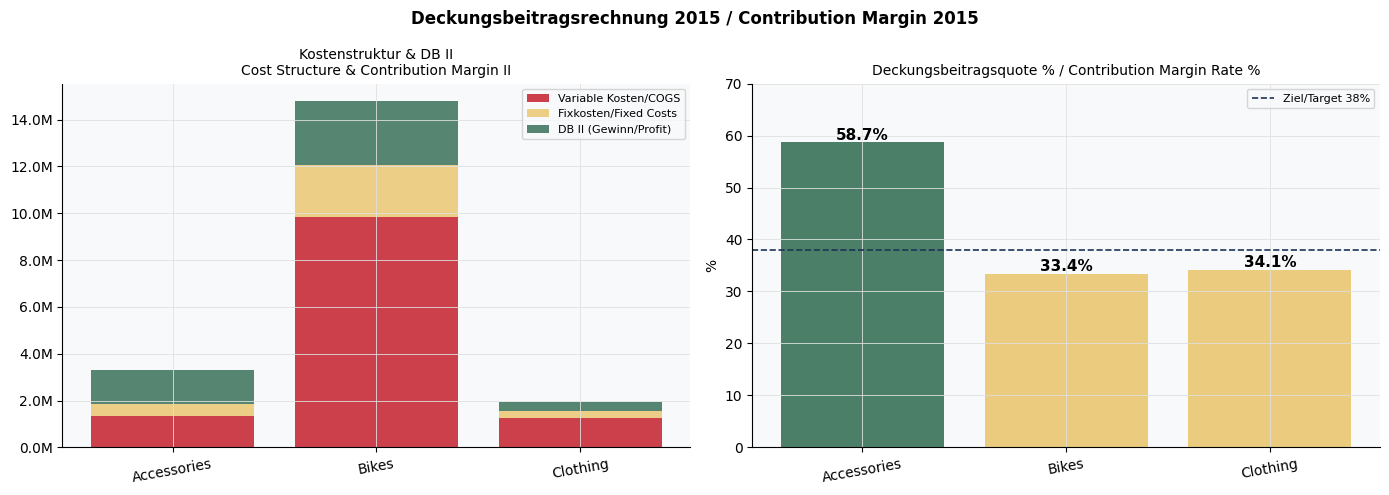

In [27]:
# ------------------------------------------------------------------
# DE: Deckungsbeitragsrechnung nach Kategorie und Land
# EN: Contribution margin by category and country
# ------------------------------------------------------------------

FIXKOSTEN_RATE = 0.15  # 15% Umsatz als Fixkosten-Proxy / 15% of revenue as fixed cost proxy

# Nach Kategorie / By category
db_cat = df[df['fiscal_year']==2015].groupby('product_category').agg(
    umsatz         = ('revenue','sum'),
    variable_kosten= ('cost',   'sum'),
    orders         = ('order_quantity','sum')
).reset_index()

db_cat['db_i']       = db_cat['umsatz'] - db_cat['variable_kosten']
db_cat['fixkosten']  = (db_cat['umsatz'] * FIXKOSTEN_RATE).round(0)
db_cat['db_ii']      = db_cat['db_i'] - db_cat['fixkosten']
db_cat['db_quote']   = (db_cat['db_i'] / db_cat['umsatz'] * 100).round(2)
db_cat['umsatz_ant'] = (db_cat['umsatz'] / db_cat['umsatz'].sum() * 100).round(1)

print('Deckungsbeitragsrechnung 2015 / Contribution Margin 2015 — nach Kategorie / by Category')
print(f'Annahme Fixkostenrate / Fixed Cost Rate: {FIXKOSTEN_RATE:.0%} vom Umsatz / of revenue')
print('─' * 95)
print(f"{'Kategorie/Category':<18} {'Umsatz':>12} {'Var.Kosten/COGS':>16} {'DB I':>12} "
      f"{'Fixkosten':>11} {'DB II':>12} {'DB-Quote%':>10} {'Anteil%':>8}")
print('─' * 95)
for _, r in db_cat.iterrows():
    print(f"{r['product_category']:<18} {r['umsatz']:>12,.0f} {r['variable_kosten']:>16,.0f} "
          f"{r['db_i']:>12,.0f} {r['fixkosten']:>11,.0f} {r['db_ii']:>12,.0f} "
          f"{r['db_quote']:>9.1f}% {r['umsatz_ant']:>7.1f}%")
print('─' * 95)
tot_u = db_cat['umsatz'].sum()
tot_dbi = db_cat['db_i'].sum()
print(f"{'GESAMT/TOTAL':<18} {tot_u:>12,.0f} {db_cat['variable_kosten'].sum():>16,.0f} "
      f"{tot_dbi:>12,.0f} {db_cat['fixkosten'].sum():>11,.0f} "
      f"{db_cat['db_ii'].sum():>12,.0f} {tot_dbi/tot_u*100:>9.1f}%")

# Visualisierung
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Deckungsbeitragsrechnung 2015 / Contribution Margin 2015', fontweight='bold', fontsize=12)

# Waterfall-style stacked bar
cats = db_cat['product_category'].tolist()
xi   = range(len(cats))
ax1.bar(xi, db_cat['variable_kosten'], label='Variable Kosten/COGS', color=C_RED,   alpha=0.8)
ax1.bar(xi, db_cat['fixkosten'],       bottom=db_cat['variable_kosten'],
        label='Fixkosten/Fixed Costs', color=C_AMBER, alpha=0.8)
ax1.bar(xi, db_cat['db_ii'],           bottom=db_cat['variable_kosten']+db_cat['fixkosten'],
        label='DB II (Gewinn/Profit)',  color=C_GREEN, alpha=0.8)
ax1.set_title('Kostenstruktur & DB II\nCost Structure & Contribution Margin II', fontsize=10)
ax1.set_xticks(list(xi)); ax1.set_xticklabels(cats, rotation=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e6:.1f}M'))
ax1.legend(fontsize=8)

# DB-Quote
colors_db = [C_GREEN if v >= 50 else (C_AMBER if v >= 30 else C_RED) for v in db_cat['db_quote']]
bars = ax2.bar(xi, db_cat['db_quote'], color=colors_db, alpha=0.85)
for bar, v in zip(bars, db_cat['db_quote']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax2.axhline(38, color=C_BLUE, linestyle='--', linewidth=1.2, label='Ziel/Target 38%')
ax2.set_title('Deckungsbeitragsquote % / Contribution Margin Rate %', fontsize=10)
ax2.set_xticks(list(xi)); ax2.set_xticklabels(cats, rotation=10)
ax2.set_ylabel('%'); ax2.set_ylim(0, 70)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/chart_contribution_margin.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Länder- & Kategorienanalyse / Country & Category Analysis

**DE:** Analyse der Performance nach Ländern und Produktkategorien — Basis für regionale Steuerungsmaßnahmen.

**EN:** Performance analysis by country and product category — basis for regional management actions.


Länderanalyse: Umsatz nach Jahr / Country Analysis: Revenue by Year
fiscal_year      2011   2012   2013   2014   2015   2016  CAGR%
country                                                        
Australia       2.53M  2.56M  4.11M  2.80M  5.71M  3.59M   7.3%
Canada          0.79M  0.84M  1.44M  1.47M  1.73M  1.66M  16.1%
France          0.95M  0.96M  1.43M  1.41M  1.88M  1.80M  13.8%
Germany         0.83M  0.84M  1.45M  1.70M  1.93M  2.22M  21.7%
United Kingdom  0.82M  0.83M  1.87M  2.01M  2.48M  2.62M  26.1%
United States   3.04M  3.15M  4.94M  4.75M  6.29M  5.81M  13.8%


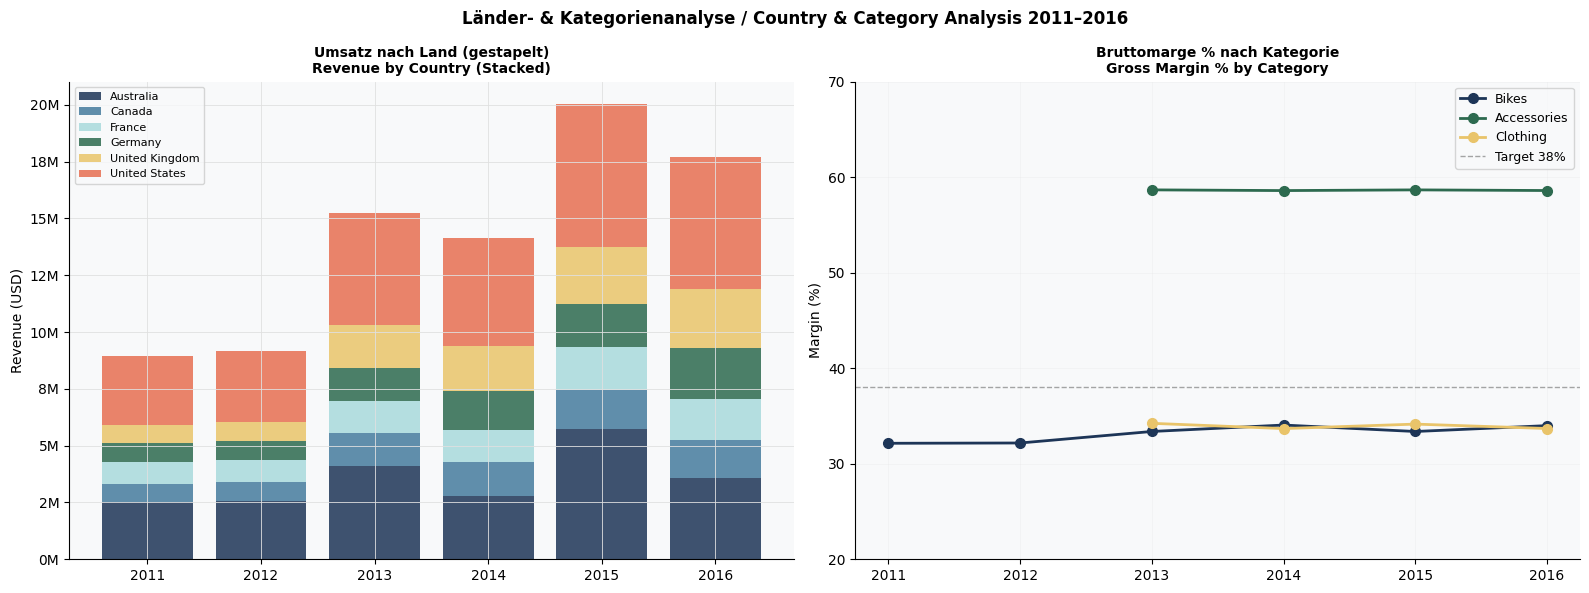

In [28]:
# ------------------------------------------------------------------
# DE: Länder- & Kategorie-Matrix
# EN: Country & Category Matrix
# ------------------------------------------------------------------

# Länderanalyse / Country analysis
ctr_all = (
    df.groupby(['fiscal_year', 'country'])
      .agg(
          revenue=('revenue', 'sum'),
          profit=('profit', 'sum')
      )
      .reset_index()
)

ctr_all['margin'] = (
    ctr_all['profit'] / ctr_all['revenue'] * 100
).round(1)

# Pivot-Tabelle Umsatz nach Jahr
ctr_pivot = ctr_all.pivot(
    index='country',
    columns='fiscal_year',
    values='revenue'
)

# CAGR berechnen falls beide Jahre vorhanden sind
if 2011 in ctr_pivot.columns and 2016 in ctr_pivot.columns:
    ctr_pivot['CAGR%'] = (
        ((ctr_pivot[2016] / ctr_pivot[2011]) ** (1 / 5) - 1)
        * 100
    ).round(1)
else:
    ctr_pivot['CAGR%'] = np.nan

# Formatierte Ausgabe
formatted = ctr_pivot.copy()

for col in formatted.columns:
    if col == 'CAGR%':
        formatted[col] = formatted[col].map(
            lambda x: f'{x:.1f}%'
            if pd.notna(x)
            else ''
        )
    else:
        formatted[col] = formatted[col].map(
            lambda x: f'{x/1e6:.2f}M'
            if pd.notna(x)
            else ''
        )

print('\nLänderanalyse: Umsatz nach Jahr / Country Analysis: Revenue by Year')
print(formatted.to_string())

# ------------------------------------------------------------------
# Visualisierung
# ------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

fig.suptitle(
    'Länder- & Kategorienanalyse / Country & Category Analysis 2011–2016',
    fontweight='bold',
    fontsize=12
)

# ------------------------------------------------------------------
# Gestapeltes Balkendiagramm nach Land
# Stacked Revenue by Country
# ------------------------------------------------------------------

countries = sorted(ctr_all['country'].unique())
years_all = sorted(ctr_all['fiscal_year'].unique())

colors_ctr = [
    C_BLUE,
    C_MED,
    C_LIGHT,
    C_GREEN,
    C_AMBER,
    '#E76F51'
]

bottom = np.zeros(len(years_all))

for country, color in zip(countries, colors_ctr):

    values = [
        ctr_all.loc[
            (ctr_all['country'] == country) &
            (ctr_all['fiscal_year'] == year),
            'revenue'
        ].sum()
        for year in years_all
    ]

    ax1.bar(
        range(len(years_all)),
        values,
        bottom=bottom,
        label=country,
        color=color,
        alpha=0.85
    )

    bottom += np.array(values)

ax1.set_title(
    'Umsatz nach Land (gestapelt)\nRevenue by Country (Stacked)',
    fontsize=10,
    fontweight='bold'
)

ax1.set_xticks(range(len(years_all)))
ax1.set_xticklabels(years_all)

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda v, _: f'{v/1e6:.0f}M'
    )
)

ax1.set_ylabel('Revenue (USD)')
ax1.legend(
    fontsize=8,
    loc='upper left'
)

# ------------------------------------------------------------------
# Kategorie-Marge über Zeit
# Category Margin over Time
# ------------------------------------------------------------------

cat_yr = (
    df.groupby(['fiscal_year', 'product_category'])
      .agg(
          revenue=('revenue', 'sum'),
          profit=('profit', 'sum')
      )
      .reset_index()
)

cat_yr['margin'] = (
    cat_yr['profit'] /
    cat_yr['revenue'] * 100
)

cat_colors = {
    'Bikes': C_BLUE,
    'Accessories': C_GREEN,
    'Clothing': C_AMBER
}

for category, color in cat_colors.items():

    d = cat_yr[
        cat_yr['product_category'] == category
    ]

    ax2.plot(
        d['fiscal_year'],
        d['margin'],
        marker='o',
        linewidth=2,
        markersize=7,
        color=color,
        label=category
    )

ax2.axhline(
    38,
    color='gray',
    linestyle='--',
    linewidth=1,
    alpha=0.7,
    label='Target 38%'
)

ax2.set_title(
    'Bruttomarge % nach Kategorie\nGross Margin % by Category',
    fontsize=10,
    fontweight='bold'
)

ax2.set_ylabel('Margin (%)')
ax2.set_ylim(20, 70)
ax2.set_xticks(years_all)

ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    '../data/processed/chart_country_category.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## 7. Rolling Forecast

**DE:** Der Rolling Forecast aktualisiert die Jahresprognose laufend auf Basis der tatsächlichen Entwicklung. Hier: Stand September 2015 → Forecast für Oktober–Dezember.

**EN:** The Rolling Forecast continuously updates the annual projection based on actual performance. Here: as of September 2015 → Forecast for October–December.

**Methode / Method:** Gleitender Durchschnitt + Saisonalitätsfaktor / Moving average + seasonality factor


Rolling Forecast — Stand / As of September 2015
──────────────────────────────────────────────────────────────────────
Actual YTD (Jan-Sep):      10.81M USD
Forecast Remaining:        6.33M USD
Annual Forecast:           17.14M USD
Annual Budget:             20.01M USD
Forecast vs Budget:        -14.33%
──────────────────────────────────────────────────────────────────────
2015-10: Forecast=2,111,384 | Plan=2,538,826 | Diff=-427,442
2015-11: Forecast=2,111,384 | Plan=2,835,230 | Diff=-723,846
2015-12: Forecast=2,111,384 | Plan=3,849,604 | Diff=-1,738,220


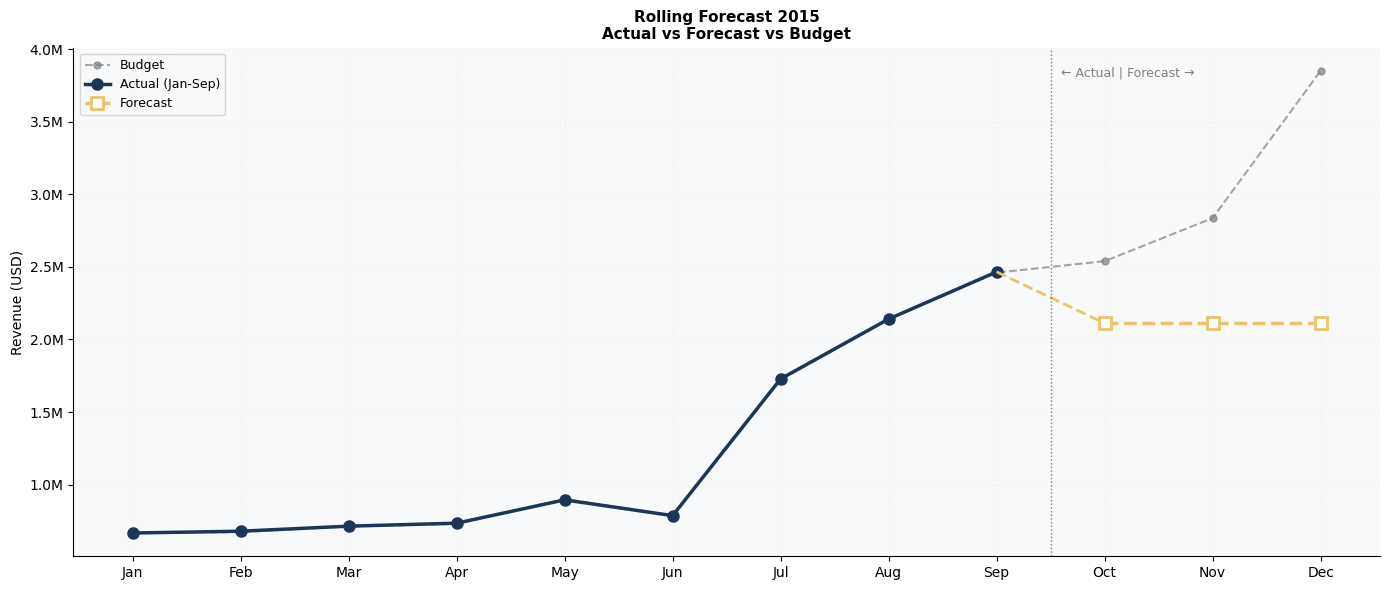


✓ Rolling Forecast saved


In [29]:
# ------------------------------------------------------------------
# DE: Rolling Forecast — Stand September 2015
# EN: Rolling Forecast — as of September 2015
# ------------------------------------------------------------------

CUTOFF_MONTH = 9  # September = last actual month

# ------------------------------------------------------------------
# Daten 2015
# ------------------------------------------------------------------

m2015 = (
    monthly[monthly['fiscal_year'] == 2015]
    .copy()
    .sort_values('year_month')
    .reset_index(drop=True)
)

m2015['month_num'] = np.arange(1, len(m2015) + 1)

actual = (
    m2015[m2015['month_num'] <= CUTOFF_MONTH]
    .copy()
)

forecast = (
    m2015[m2015['month_num'] > CUTOFF_MONTH]
    .copy()
)

# ------------------------------------------------------------------
# Seasonality from 2014
# ------------------------------------------------------------------

m2014 = (
    monthly[monthly['fiscal_year'] == 2014]
    .copy()
    .sort_values('year_month')
    .reset_index(drop=True)
)

if m2014.empty:
    raise ValueError(
        'No data available for fiscal year 2014.'
    )

m2014['month_num'] = np.arange(1, len(m2014) + 1)

total_2014 = m2014['revenue'].sum()

if total_2014 == 0:
    raise ValueError(
        '2014 revenue total equals zero.'
    )

m2014['season_factor'] = (
    m2014['revenue']
    / (total_2014 / len(m2014))
)

seasonality = (
    m2014
    .set_index('month_num')['season_factor']
)

# ------------------------------------------------------------------
# Forecast Basis
# ------------------------------------------------------------------

avg_last3 = actual.tail(3)['revenue'].mean()

forecast['revenue_forecast'] = (
    forecast['month_num']
    .map(seasonality)
    .fillna(1)
    .mul(avg_last3)
    .round(0)
)

# ------------------------------------------------------------------
# Annual Projection
# ------------------------------------------------------------------

ist_ytd = actual['revenue'].sum()

forecast_rest = (
    forecast['revenue_forecast']
    .sum()
)

jahresprognose = (
    ist_ytd + forecast_rest
)

budget_total = (
    m2015['revenue_plan']
    .sum()
)

budget_variance_pct = (
    (jahresprognose - budget_total)
    / budget_total
    * 100
)

# ------------------------------------------------------------------
# Console Output
# ------------------------------------------------------------------

fmt_money = lambda x: f'{x/1e6:,.2f}M USD'

print()
print('Rolling Forecast — Stand / As of September 2015')
print('─' * 70)

print(
    f'Actual YTD (Jan-Sep):      {fmt_money(ist_ytd)}'
)

print(
    f'Forecast Remaining:        {fmt_money(forecast_rest)}'
)

print(
    f'Annual Forecast:           {fmt_money(jahresprognose)}'
)

print(
    f'Annual Budget:             {fmt_money(budget_total)}'
)

print(
    f'Forecast vs Budget:        {budget_variance_pct:+.2f}%'
)

print('─' * 70)

for _, r in forecast.iterrows():

    diff = (
        r['revenue_forecast']
        - r['revenue_plan']
    )

    print(
        f'{r["year_month_str"]}: '
        f'Forecast={r["revenue_forecast"]:,.0f} | '
        f'Plan={r["revenue_plan"]:,.0f} | '
        f'Diff={diff:+,.0f}'
    )

# ------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 6)
)

months_lbl = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

xi = np.arange(len(m2015))

# ------------------------------------------------------------------
# Budget
# ------------------------------------------------------------------

ax.plot(
    xi,
    m2015['revenue_plan'],
    'o--',
    color='gray',
    linewidth=1.5,
    markersize=5,
    alpha=0.7,
    label='Budget'
)

# ------------------------------------------------------------------
# Actual
# ------------------------------------------------------------------

ax.plot(
    actual['month_num'] - 1,
    actual['revenue'],
    'o-',
    color=C_BLUE,
    linewidth=2.5,
    markersize=8,
    label='Actual (Jan-Sep)'
)

# ------------------------------------------------------------------
# Forecast
# ------------------------------------------------------------------

if not forecast.empty:

    connect_x = [
        actual.iloc[-1]['month_num'] - 1,
        forecast.iloc[0]['month_num'] - 1
    ]

    connect_y = [
        actual.iloc[-1]['revenue'],
        forecast.iloc[0]['revenue_forecast']
    ]

    ax.plot(
        connect_x,
        connect_y,
        '--',
        color=C_AMBER,
        linewidth=2
    )

    ax.plot(
        forecast['month_num'] - 1,
        forecast['revenue_forecast'],
        's--',
        color=C_AMBER,
        linewidth=2.5,
        markersize=8,
        markerfacecolor='white',
        markeredgewidth=2,
        label='Forecast'
    )

# ------------------------------------------------------------------
# Separator
# ------------------------------------------------------------------

ax.axvline(
    CUTOFF_MONTH - 0.5,
    color='black',
    linewidth=1,
    linestyle=':',
    alpha=0.5
)

ax.text(
    CUTOFF_MONTH - 0.4,
    ax.get_ylim()[1] * 0.95,
    '← Actual | Forecast →',
    fontsize=9,
    color='gray'
)

# ------------------------------------------------------------------
# Formatting
# ------------------------------------------------------------------

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda v, _: f'{v/1e6:.1f}M'
    )
)

ax.set_xticks(np.arange(12))
ax.set_xticklabels(months_lbl)

ax.set_title(
    'Rolling Forecast 2015\n'
    'Actual vs Forecast vs Budget',
    fontsize=11,
    fontweight='bold'
)

ax.set_ylabel('Revenue (USD)')

ax.legend(fontsize=9)

ax.grid(
    alpha=0.25,
    linestyle='--'
)

plt.tight_layout()

plt.savefig(
    '../data/processed/chart_rolling_forecast.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print()
print('✓ Rolling Forecast saved')

## 8. Management Summary Export

**DE:** Zusammenfassung aller Controlling-Ergebnisse für den Management-Report.

**EN:** Summary of all controlling results for the management report.

In [30]:
# ------------------------------------------------------------------
# DE: Alle Ergebnisse als CSV exportieren
# EN: Export all results as CSV
# ------------------------------------------------------------------

monthly.to_csv('../data/processed/controlling_monthly.csv',    index=False, encoding='utf-8-sig')
annual.to_csv( '../data/processed/controlling_annual.csv',     index=False, encoding='utf-8-sig')
db_cat.to_csv( '../data/processed/controlling_db_category.csv',index=False, encoding='utf-8-sig')
cat_2015.to_csv('../data/processed/controlling_variance.csv',  index=False, encoding='utf-8-sig')

print('✓ Gespeichert / Saved:')
print('  → data/processed/controlling_monthly.csv')
print('  → data/processed/controlling_annual.csv')
print('  → data/processed/controlling_db_category.csv')
print('  → data/processed/controlling_variance.csv')

print()
print('=' * 60)
print('MANAGEMENT SUMMARY 2015 / УПРАВЛІНСЬКИЙ ЗВІТ')
print('=' * 60)
y = annual[annual['fiscal_year']==2015].iloc[0]
print(f'Umsatz/Revenue:         {y.revenue:>12,.0f} USD (+{y.revenue_yoy:.1f}% YoY)')
print(f'Bruttoergebnis/GP:      {y.profit:>12,.0f} USD (+{y.profit_yoy:.1f}% YoY)')
print(f'Bruttomarge/Margin:     {y.margin_pct:>11.1f}%')
print(f'Plan-Abweichung/Var:    {y.rev_var_pct:>+11.2f}%')
print(f'Beste Kategorie/Top:    Accessories (Marge: 58.7%)')
print(f'Stärkste Region/Top:    USA (Revenue: 6.3M USD)')
print('=' * 60)
print('\nNächster Schritt / Next step: Modul 3 — Dashboard')

✓ Gespeichert / Saved:
  → data/processed/controlling_monthly.csv
  → data/processed/controlling_annual.csv
  → data/processed/controlling_db_category.csv
  → data/processed/controlling_variance.csv

MANAGEMENT SUMMARY 2015 / УПРАВЛІНСЬКИЙ ЗВІТ
Umsatz/Revenue:           20,023,991 USD (+41.5% YoY)
Bruttoergebnis/GP:         7,528,563 USD (+28.4% YoY)
Bruttomarge/Margin:            37.6%
Plan-Abweichung/Var:          +0.06%
Beste Kategorie/Top:    Accessories (Marge: 58.7%)
Stärkste Region/Top:    USA (Revenue: 6.3M USD)

Nächster Schritt / Next step: Modul 3 — Dashboard
